<a href="https://colab.research.google.com/github/sk27110/ML/blob/HW3/HW3_uplift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Задание по Uplift-моделированию </h1>

<h2>Введение</h2>

Перед вами типичная задача, возникающая при работе с моделями кампейнинга в банке: заказчик запустил несколько пилотов по взаимодействию с клиентами с помощью разных каналов: push в мобильном приложении, sms, баннеры в мобильном приложении и реклама в других приложениях экосистемы. Заказчик хотел бы понимать, какой канал взаимодействия с клиентом наиболее эффективен для каждого клиента из клиентской базы. Кампании планируются и запускаются в ежемесячном режиме. Иными словами, заказчик хотел бы в идеале ежемесячно получать список клиентов, которым необходимо отправить коммуникацию с указанием канала и прироста вероятности покупки в случае, если клиенту отправят коммуникацию по сравнению с тем случаем, когда клиенту коммуникацию не отправят.

<b>Таким образом: </b>
1.	У нас есть база клиентов (клиенты, имеющие id в банке). По данной базе осуществляется рассылка тех или иных стимулирующих коммуникаций по различным продуктам, каналам (например SMS, Push, баннеры в мобильном приложении и т.д.) и сегментам клиентов
2.	Признаковое описание клиента состоит из различных агрегатов действий клиента за месяц или его объективных характеристик: например, средняя сумма средств на депозитах за месяц, среднее число кликов клиента в день за месяц в разделе "инвестиции" в мобильном приложении или возраст клиента
3.	При формировании обучающей/тестовой выборки допускается, что один и тот же клиент за разные месяцы — это разные объекты. То есть допускается, что клиент в феврале и клиент в марте — это разные клиенты (то есть мы можем оперировать с ними как с разными сущностями).
4.	Агрегаты действий клиента за месяц появляются примерно 10 числа следующего месяца. То есть, например, агрегаты за декабрь появляются 10 января. В свою очередь списки клиентов, которым необходимо осуществить рассылку должны быть сформированы ориентировочно 20 числа предыдущего месяца. Таким образом, <b> модель должна быть обучена делать предсказания с лагом в два месяца </b>, то есть должна делать предсказание на март по клиентским агрегатам за январь. Обязательно учтите это при обучении модели (в противном случае можно получить лик таргета, так как часто величину, которую мы предсказываем уже есть в клиентских агрегатах, но смещенная на два месяца).


## Оценивание задания:

Всего за задание можно получить 50 первичных баллов, которые затем переводятся в 10-балльную шкалу делением не 5.

Скачаем архив с данными по ссылке и разархивируем.

In [1]:
!pip install gdown -q

In [2]:
import gdown

url = 'https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO'
output = 'Data.zip'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO
From (redirected): https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO&confirm=t&uuid=b1a28004-0196-4ad2-a0e8-9deb11033f3d
To: /content/Data.zip
100%|██████████| 289M/289M [00:02<00:00, 113MB/s]


'Data.zip'

In [3]:
import zipfile

with zipfile.ZipFile('Data.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

<h2>Описание данных</h2>

Перед вами несколько наборов данных, на основе которых вам будет необходимо обучить Uplift модели, сделать прогноз на нужный месяц и решить, кому из клиентов отправлять коммуникацию, а кому коммуникацию отправлять не следует.

<h3>Features </h3> Признаки клиентов, клиентские агрегаты, которые описывают поведение клиентов <br>

1. user_id - id клиента
2. report_dt - месяц, на который актуальны признаки
3. city - город, в котором живет клиент
4. age - возраст клиента
5. x1 – x9 - числовые признаки клиента, характеризующие поведение клиента

Первичный ключ таблицы - user_id + report_dt

<h3> Contracts </h3> Таблица с покупками продуктов.

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h3> Campaings </h3> Кампании, которые проводились (под кампанией мы понимаем рассылку sms, push и т.д).

1. campaing_id - id кампании, первичный ключ таблицы
2. product_id - продукт, по которому проводилась кампания (считаем, что продукты не конкурируют друг с другом)
3. channel - канал, в котором проводилась кампания


<h3> People_in_campaings </h3> Люди, которые принимали участие в кампаниях.

1. campaing_id - id кампании
2. user_id - id пользователя, который попал в кампанию
3. флаг целевой (1) и контрольной (0) группы (целевая группа - это те, кто получил коммуникацию, а контрольная - те, кто нет)
4. delivery_ts - timestamp, когда клиенту фактически была доставлена коммуникация (для контрольной группы nan, подумайте почему)

Первичный ключ данной таблицы - user_id + campaing_id


<h1> Постановка задачи </h1> В ноябре 2024 проводилось несколько кампаний по продукту с id 0001 (фактически клиенту рассылалось одно и тоже сообщение, но в разных каналах). Вам необходимо по данным кампаниям построить модель, которая будет определять лучший канал коммуникации каждого клиента и определить, кому из клиентов в марте 2025 отправить какую коммуникацию, а кому коммуникацию вообще отправлять не следует.
Ответ нужно представить в следующем виде (report_dt – дата фичей):

<table>
  <thead>
    <tr>
      <th>user_id</th>
      <th>report_dt</th>
      <th>channel</th>
      <th>uplift</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>10045</td>
      <td>2025-01-31</td>
      <td>banner</td>
      <td>0.07</td>
    </tr>
    <tr>
      <td>10046</td>
      <td>2025-01-31</td>
      <td>no_comm</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>10047</td>
      <td>2025-01-31</td>
      <td>sms</td>
      <td>0.23</td>
    </tr>
    <tr>
      <td>10048</td>
      <td>2025-01-31</td>
      <td>push</td>
      <td>0.19</td>
    </tr>
  </tbody>
</table>

<h1> Декомпозиция задачи </h1>

<h2> 1.	Сбор и анализ таргета (18 баллов)</h2>

Прежде всего, вам необходимо собрать целевое событие, которое вы собираетесь прогнозировать. В данном случае целевое событие - это покупка продукта 0001 пользователем, участвовавшем в кампании. Обратите внимание, что не все пользователи получают коммуникацию одновременно (delivery_ts в таблице People_in_campaings). Согласно правилу, согласованному с заказчиком, <b> человек из целевой группы купил продукт после коммуникации - это значит, что он купил его в течение 2х недель после получения сообщения, а человек из контрольной - в течение 3х недель с момента старта кампании (старт кампании - начало месяца). </b> То есть для определенной кампании, для каждого клиента, попавшего в кампанию, вам надо будет найти его покупки данного продукта, а потом основываяся на данном правиле превратить покупки в 0 или 1. <br> На выходе у вас должен появиться таблица с целевым действием для каждого канала (колонки client_id, report_dt,  target), где таргет - это бинарная переменная (0 или 1). Колонка report_dt вам нужна как техническая колонка для дальнейших джоинов.<br><br>

Проведите анализ полученных данных (до присоединения клиентских агрегатов). Какие проблемы и сложности в данных вы обнаружили? Что с ними можно сделать? Какая из кампаний наиболее эффективная? Подготовьте выводы по полученным инсайтам.


**Комментарий по заданиям и оцениванию:**

* Вы должны самостоятельно сделать join нескольких таблиц, самостоятельно собрать целевое действие

* Представлены 4 различных канала, за таргет по каждому из каналов можно получить **максимум 2 балла**:
    * 1 балл за то, что просчитано целевое действие для целевой группы (покупка в
течение одной-двух недель с момента получения коммуникации)
    * 1 балл за то, что просчитано целевое действие для контрольной группы (покупка в течение двух-трех недель с момента старта кампании) и сделана таблица в требуемом формате

* Обратите внимание, что не во всех кампаниях содержатся корректные данные для проведения моделирования, и вам необходимо провести анализ данных и в случае выявленных некорректностей - описать их, и не проводить моделирование для "сломанной" кампании  
    * За данный анализ можно получить **8 баллов**

* Вы должны оценить эффективность кампаний по uplift (cреднее значение таргета в целевой минус среднее значение таргета в контрольной группе)
    * За данный анализ можно получить **2 балла**

In [4]:
import pandas as pd

In [5]:
features = pd.read_csv('/content/ДЗ по Uplift обновленное/AGGS_FINAL.csv')
features = features.drop('Unnamed: 0', axis=1)
contracts = pd.read_csv('/content/ДЗ по Uplift обновленное/CONTRACTS_FINAL.csv')
contracts = contracts.drop('Unnamed: 0', axis=1)
campaings = pd.read_csv('/content/ДЗ по Uplift обновленное/CAMPAINGS.csv')
campaings = campaings.drop('Unnamed: 0', axis=1)
people_in_campaings = pd.read_csv('/content/ДЗ по Uplift обновленное/PEOPLE_IN_CAMPAINGS_FINAL.csv')
people_in_campaings = people_in_campaings.drop('Unnamed: 0', axis=1)

In [6]:
campaings

,campaing_id,product_id,channel
0,iddqd,1,push
1,idclip,1,sms
2,iddt,1,banner
3,idkfa,1,other_ads


In [7]:
contracts.shape[0] == contracts['user_id'].unique().shape[0]

True

У каждого пользователя не более одной покупки, можно смело мерджить

In [8]:
people_in_campaings['delivery_date'] = pd.to_datetime(
    people_in_campaings['delivery_date'], errors='coerce'
)

contracts['contract_date'] = pd.to_datetime(
    contracts['contract_date'], errors='coerce'
)

In [9]:
df = people_in_campaings.merge(
    contracts,
    on='user_id',
    how='left'
)


In [10]:
df[df['t_flag']==0]['user_id'].duplicated().sum()


0

In [11]:
df.head()

,campaing_id,user_id,t_flag,delivery_date,contract_date,product_id,contract_id
0,idclip,1099975,1,2024-11-06,2024-11-11,1.0,0001_2024-11-11_1099975
1,iddqd,1162,1,2024-11-08,2024-11-13,1.0,0001_2024-11-13_1162
2,iddqd,42991,1,2024-11-07,NaT,NaN,NaN
3,idclip,142343,0,NaT,2024-11-17,1.0,0001_2024-11-17_142343
4,iddqd,24623,0,NaT,NaT,NaN,NaN


In [12]:
from datetime import timedelta

def get_target(row):
    if row['t_flag'] == 0:
        campaign_start = pd.Timestamp("2024-11-01")
        if pd.isna(row['contract_date']):
            return 0
        return int(campaign_start <= row['contract_date'] <= campaign_start + timedelta(days=21))

    if pd.isna(row['delivery_date']) or pd.isna(row['contract_date']):
        return 0

    return int(row['delivery_date'] <= row['contract_date'] <= row['delivery_date'] + timedelta(days=14))


In [13]:
df['target'] = df.apply(get_target, axis=1)

In [14]:
df.head()

,campaing_id,user_id,t_flag,delivery_date,contract_date,product_id,contract_id,target
0,idclip,1099975,1,2024-11-06,2024-11-11,1.0,0001_2024-11-11_1099975,1
1,iddqd,1162,1,2024-11-08,2024-11-13,1.0,0001_2024-11-13_1162,1
2,iddqd,42991,1,2024-11-07,NaT,NaN,NaN,0
3,idclip,142343,0,NaT,2024-11-17,1.0,0001_2024-11-17_142343,1
4,iddqd,24623,0,NaT,NaT,NaN,NaN,0


### Изучим кампанию idclip

In [15]:
df_idclip = df[df['campaing_id'] == 'idclip']

In [16]:
df_idclip['t_flag'].value_counts(normalize=True)

,proportion
t_flag,
1,0.5
0,0.5


In [17]:
df_idclip['contract_date'].isna().mean()

0.17215833333333333

In [18]:
df_idclip.groupby('t_flag')['target'].mean()

,target
t_flag,
0,0.684917
1,0.201167


In [19]:
mean_treat = df_idclip[df_idclip['t_flag'] == 1]['target'].mean()
mean_control = df_idclip[df_idclip['t_flag'] == 0]['target'].mean()

uplift = mean_treat - mean_control
print(uplift)

-0.48374999999999996


Получили отрицательный uplift. Это говорит о проблемах в данных. Эту кампанию мы использовать не будем.

### Изучим iddqd кампанию

In [20]:
df_iddqd = df[df['campaing_id'] == 'iddqd']

In [21]:
df_iddqd['t_flag'].value_counts(normalize=True)

,proportion
t_flag,
1,0.5
0,0.5


In [22]:
df_iddqd['contract_date'].isna().mean()

0.4707125

In [23]:
df_iddqd.groupby('t_flag')['target'].mean()

,target
t_flag,
0,0.202150
1,0.601738


In [24]:
mean_treat = df_iddqd[df_iddqd['t_flag'] == 1]['target'].mean()
mean_control = df_iddqd[df_iddqd['t_flag'] == 0]['target'].mean()

uplift = mean_treat - mean_control
print(uplift)

0.39958750000000004


Тут вроде бы все ок

In [25]:
df['campaing_id'].unique()

array(['idclip', 'iddqd', 'iddt', 'idkfa'], dtype=object)

### Посмотрим на iddt кампанию

In [26]:
df_iddt = df[df['campaing_id'] == 'iddt']

In [27]:
df_iddt['t_flag'].value_counts(normalize=True)

,proportion
t_flag,
0,0.5
1,0.5


In [28]:
df_iddt['contract_date'].isna().mean()

0.371075

In [29]:
df_iddt.groupby('t_flag')['target'].mean()

,target
t_flag,
0,0.400733
1,0.602717


In [30]:
mean_treat = df_iddt[df_iddt['t_flag'] == 1]['target'].mean()
mean_control = df_iddt[df_iddt['t_flag'] == 0]['target'].mean()

uplift = mean_treat - mean_control
print(uplift)

0.20198333333333335


### Теперь idkfa

In [31]:
df_idkfa = df[df['campaing_id'] == 'idkfa']

In [32]:
df_idkfa['t_flag'].value_counts(normalize=True)

,proportion
t_flag,
1,0.5
0,0.5


In [33]:
df_idkfa['contract_date'].isna().mean()

0.3488583333333333

In [34]:
df_idkfa.groupby('t_flag')['target'].mean()

,target
t_flag,
0,0.400733
1,0.602717


In [35]:
mean_treat = df_idkfa[df_idkfa['t_flag'] == 1]['target'].mean()
mean_control = df_idkfa[df_idkfa['t_flag'] == 0]['target'].mean()

uplift = mean_treat - mean_control
print(uplift)

0.20198333333333335


У idfka и iddt одинаковое распределение таргета. Это странно. Проверим, что с данными:

In [36]:
set(df_idkfa['user_id']) == set(df_iddt['user_id'])


False

In [37]:
print(df_idkfa['t_flag'].value_counts(normalize=True))
print(df_iddt['t_flag'].value_counts(normalize=True))


t_flag
1    0.5
0    0.5
Name: proportion, dtype: float64
t_flag
0    0.5
1    0.5
Name: proportion, dtype: float64


In [38]:
print(df_idkfa.groupby('user_id')['delivery_date'].nunique().value_counts())
print(df_iddt.groupby('user_id')['delivery_date'].nunique().value_counts())


delivery_date
1    60000
0    60000
Name: count, dtype: int64
delivery_date
0    60000
1    60000
Name: count, dtype: int64


In [39]:
print(df_idkfa['contract_date'].describe())
print(df_iddt['contract_date'].describe())

count                            78137
mean     2024-11-12 15:29:57.258661120
min                2024-11-01 00:00:00
25%                2024-11-07 00:00:00
50%                2024-11-13 00:00:00
75%                2024-11-16 00:00:00
max                2024-11-28 00:00:00
Name: contract_date, dtype: object
count                            75471
mean     2024-11-12 10:53:51.514091520
min                2024-11-01 00:00:00
25%                2024-11-07 00:00:00
50%                2024-11-13 00:00:00
75%                2024-11-16 00:00:00
max                2024-11-28 00:00:00
Name: contract_date, dtype: object


In [40]:
print(df_idkfa['delivery_date'].describe())
print(df_iddt['delivery_date'].describe())


count                         60000
mean     2024-11-05 19:18:53.280000
min             2024-11-04 00:00:00
25%             2024-11-05 00:00:00
50%             2024-11-06 00:00:00
75%             2024-11-07 00:00:00
max             2024-11-08 00:00:00
Name: delivery_date, dtype: object
count                         60000
mean     2024-11-06 00:05:36.960000
min             2024-11-04 00:00:00
25%             2024-11-05 00:00:00
50%             2024-11-06 00:00:00
75%             2024-11-07 00:00:00
max             2024-11-08 00:00:00
Name: delivery_date, dtype: object


In [41]:
print(len(df_idkfa), df_idkfa['user_id'].nunique())
print(len(df_iddt), df_iddt['user_id'].nunique())

120000 120000
120000 120000


In [42]:
df[df.duplicated(subset=['user_id'], keep=False)].shape


(120000, 8)

In [43]:
df_idkfa.sort_values('user_id')['target'].reset_index(drop=True).equals(
    df_iddt.sort_values('user_id')['target'].reset_index(drop=True)
)


False

In [44]:
set_idkfa = set(people_in_campaings[people_in_campaings['campaing_id']=='idkfa']['user_id'])
set_iddt = set(people_in_campaings[people_in_campaings['campaing_id']=='iddt']['user_id'])

set_idkfa == set_iddt

False

In [45]:
import pandas as pd

campaign_users = {
    'iddqd': set(df_iddqd['user_id']),
    'idclip': set(df_idclip['user_id']),
    'iddt': set(df_iddt['user_id']),
    'idkfa': set(df_idkfa['user_id'])
}

campaign_names = list(campaign_users.keys())
matrix = pd.DataFrame(index=campaign_names, columns=campaign_names, dtype=float)

for c1 in campaign_names:
    for c2 in campaign_names:
        intersection = campaign_users[c1] & campaign_users[c2]
        perc_c1 = len(intersection) / len(campaign_users[c1]) * 100
        perc_c2 = len(intersection) / len(campaign_users[c2]) * 100
        matrix.loc[c1, c2] = perc_c1

print(matrix)


        iddqd  idclip   iddt  idkfa
iddqd   100.0    37.5    0.0    0.0
idclip   50.0   100.0    0.0    0.0
iddt      0.0     0.0  100.0    0.0
idkfa     0.0     0.0    0.0  100.0


Вроде данные разные, но распределение одинаковое.

### ваши выводы здесь

Итого: убираем idclip, так как uplift на ней отрицателен. Так же уберем iddt, так как у iddt и idkfa одинаковое распределение таргета.

По поводу uplift:
1) У idclip uplift отрицателен
2) У iddqd в районе 0.40. Это очень хороший результат  
3) У idkfa и iddt uplift на уровне 0.20, что тоже неплохо.

По сути мы получили 4 таблицы с пользователями и таргетом, что и требовалось. Можем идти дальше


In [46]:
df_idkfa
df_iddqd # с этими штуками работает далее

,campaing_id,user_id,t_flag,delivery_date,contract_date,product_id,contract_id,target
1,iddqd,1162,1,2024-11-08,2024-11-13,1.0,0001_2024-11-13_1162,1
2,iddqd,42991,1,2024-11-07,NaT,NaN,NaN,0
4,iddqd,24623,0,NaT,NaT,NaN,NaN,0
12,iddqd,116064,0,NaT,2024-11-08,1.0,0001_2024-11-08_116064,1
17,iddqd,139714,0,NaT,NaT,NaN,NaN,0
...,...,...,...,...,...,...,...,...
519987,iddqd,94299,0,NaT,NaT,NaN,NaN,0
519992,iddqd,98949,0,NaT,NaT,NaN,NaN,0
519996,iddqd,131927,1,2024-11-06,2024-11-27,1.0,0001_2024-11-27_131927,0
519998,iddqd,73995,0,NaT,NaT,NaN,NaN,0


<h2> 2. Клиентские агрегаты (12 баллов)</h2>

Присоедините клиентские агрегаты (будьте внимательны, присоедините агрегаты за корректный месяц) и изучите полученные данные.

**Комментарий по заданиям и оцениванию:**

* Вы должны корректно присоединить клиентские агрегаты со смещением на два месяца, чтобы не было лика таргета. За данное действие можно получить **4 балла**

* Далее вы должен сделать UPLIFT EDA, которые обсуждались на лекции и показывались в практических ноутбуках. В ходе анализа вы должны проверить корректность данных по рекламным кампаниям и решить, что делать со "сломанными" кампаниями. По итогам анализа подготовьте выводы. За данное действие можно получить **8 баллов**

In [47]:
df_idkfa.drop(['campaing_id', 'delivery_date', 'contract_date'], axis=1, inplace=True)
df_iddqd.drop(['campaing_id', 'delivery_date', 'contract_date'], axis=1, inplace=True)

/tmp/ipython-input-2675956754.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_idkfa.drop(['campaing_id', 'delivery_date', 'contract_date'], axis=1, inplace=True)
/tmp/ipython-input-2675956754.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_iddqd.drop(['campaing_id', 'delivery_date', 'contract_date'], axis=1, inplace=True)


In [48]:
features['report_dt'] = pd.to_datetime(features['report_dt'])

In [49]:
features_september = features[
    (features['report_dt'].dt.year == 2024) &
    (features['report_dt'].dt.month == 9)
]

In [50]:
df_idkfa_full = df_idkfa.merge(
    features_september,
    on='user_id',
    how='left'
)

df_iddqd_full = df_iddqd.merge(
    features_september,
    on='user_id',
    how='left'
)

In [51]:
df = pd.concat([df_idkfa_full, df_iddqd_full], ignore_index=True)


In [52]:
df_train = df.drop(['user_id', 'product_id', 'contract_id'], axis=1)

In [53]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280000 entries, 0 to 279999
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   t_flag     280000 non-null  int64         
 1   target     280000 non-null  int64         
 2   x1         280000 non-null  float64       
 3   x2         280000 non-null  float64       
 4   x3         280000 non-null  float64       
 5   x4         280000 non-null  float64       
 6   x5         280000 non-null  float64       
 7   x6         280000 non-null  float64       
 8   x7         280000 non-null  float64       
 9   x8         280000 non-null  float64       
 10  x9         280000 non-null  float64       
 11  report_dt  280000 non-null  datetime64[ns]
 12  age        280000 non-null  int64         
 13  city       280000 non-null  object        
dtypes: datetime64[ns](1), float64(9), int64(3), object(1)
memory usage: 29.9+ MB


In [54]:
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
df_train.groupby('t_flag')[numeric_cols].mean()


,t_flag,target,x1,x2,x3,x4,x5,x6,x7,x8,x9,age
t_flag,,,,,,,,,,,,
0,0.0,0.287257,0.259363,0.135533,0.649282,-0.432780,0.338814,-0.001661,0.142543,0.142887,0.200558,32.530171
1,1.0,0.602157,0.262050,0.147398,0.656097,-0.426347,0.342336,-0.000291,0.141456,0.140609,0.198851,32.468064


In [55]:
df.groupby(by='t_flag')[numeric_cols].median()

,t_flag,target,x1,x2,x3,x4,x5,x6,x7,x8,x9,age
t_flag,,,,,,,,,,,,
0,0.0,0.0,0.418024,0.210933,0.693269,-0.490719,0.00000,0.001099,0.165318,0.129482,0.100164,33.0
1,1.0,1.0,0.414908,0.228345,0.703573,-0.482225,0.35227,0.000277,0.151969,0.120817,0.103975,32.0


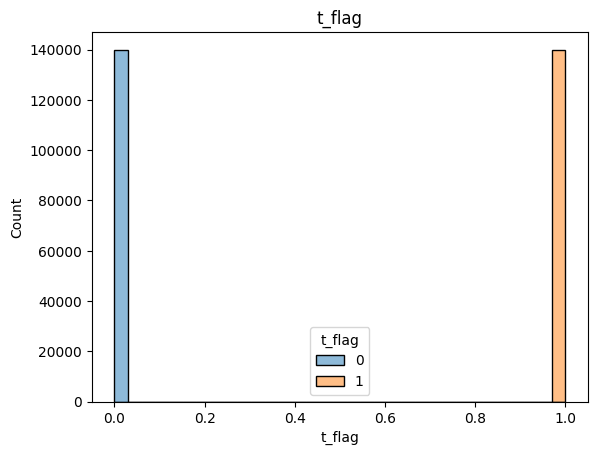

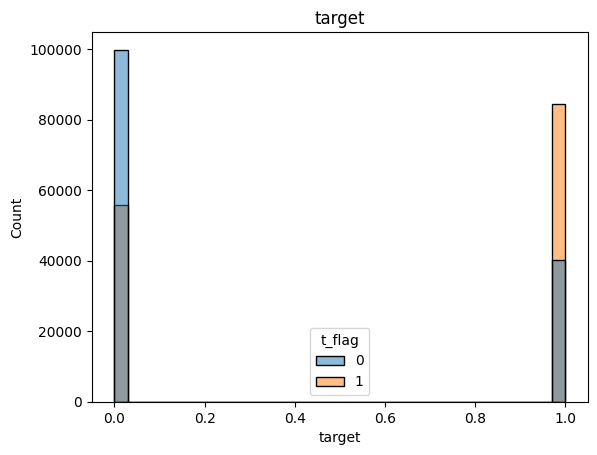

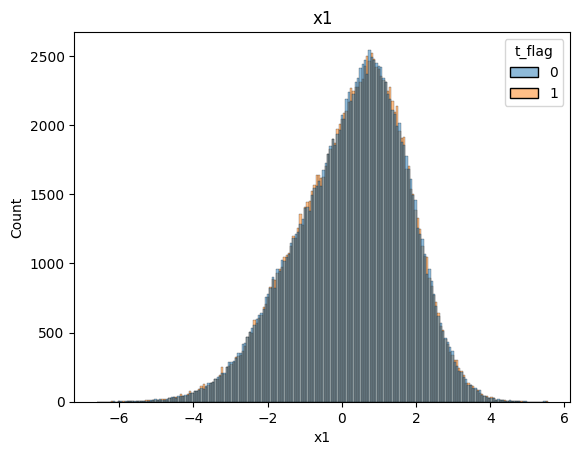

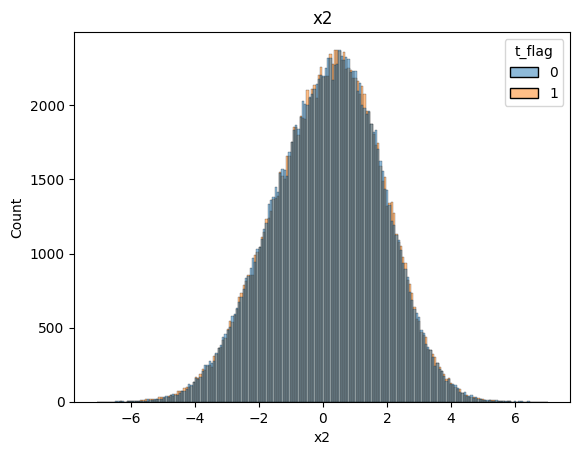

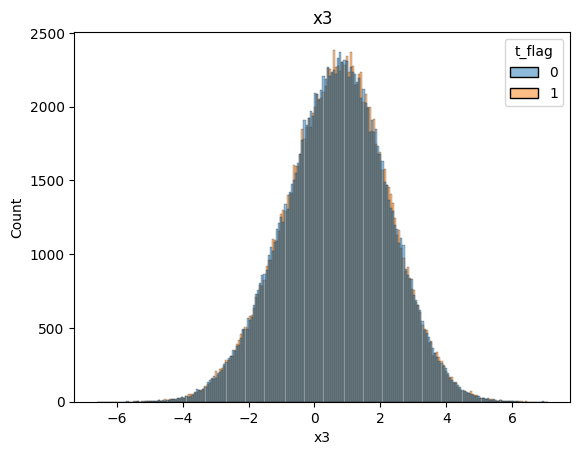

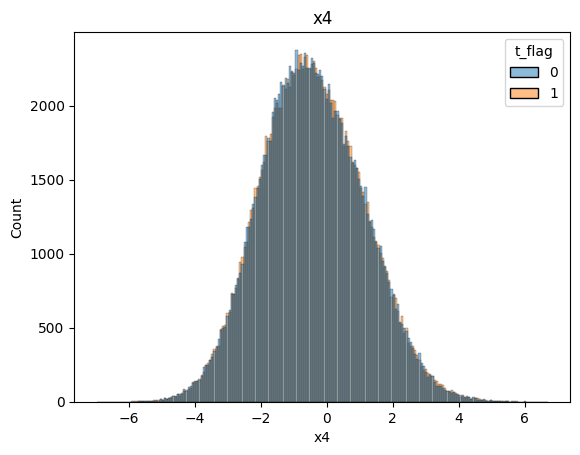

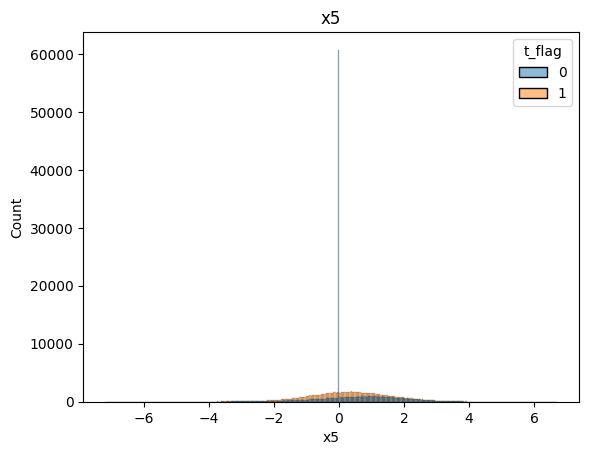

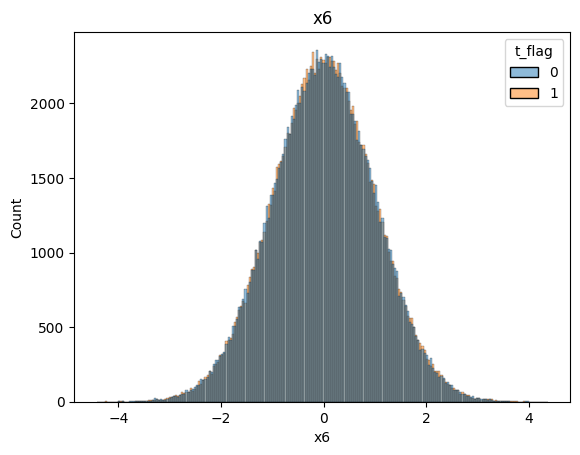

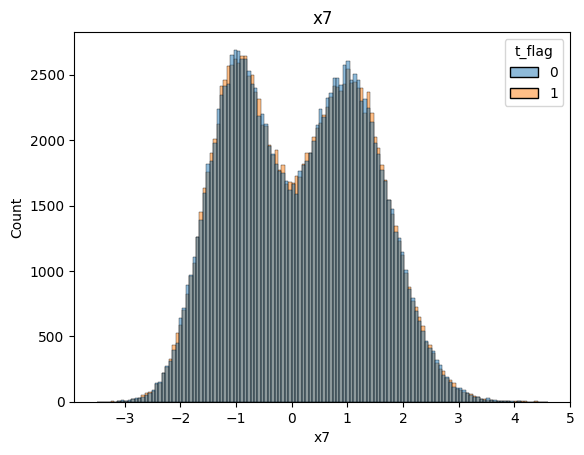

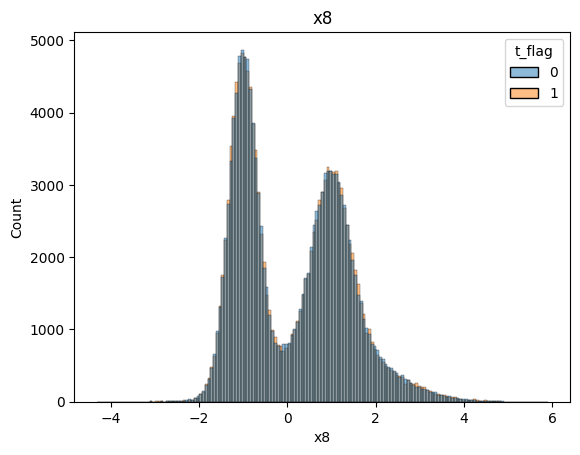

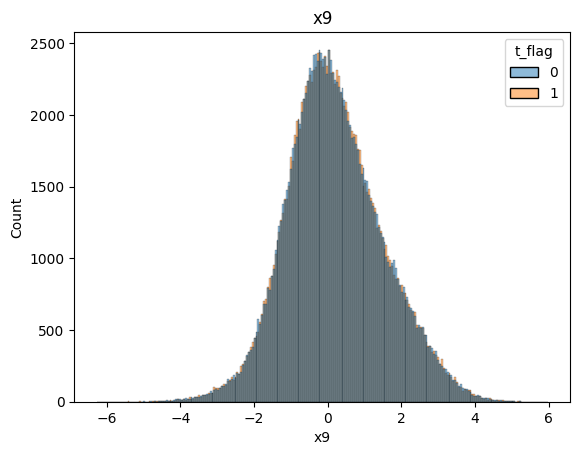

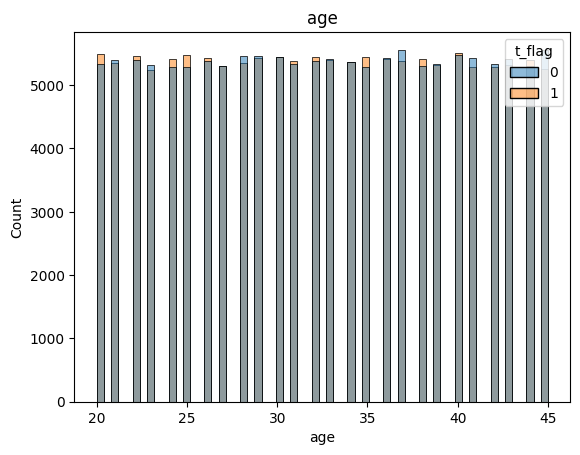

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_cols:
    sns.histplot(data = df, x=col, hue='t_flag').set_title(col)
    plt.show()

In [57]:
clear_df_train = df_train.drop('x5', axis=1)

In [58]:
!pip install --no-cache-dir psi


  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
ERROR: Failed to build 'psi' when getting requirements to build wheel


In [59]:
import numpy as np
import pandas as pd


#psi не хотел работать, поэтому я попросил многоуважаемый чат гпт написать мне эту функцию)
def calculate_psi(expected, actual, buckets=10):
    """
    Calculate PSI (Population Stability Index)

    expected — распределение в контрольной выборке (Series)
    actual — распределение в тестовой выборке (Series)
    buckets — количество бинов для PSI (обычно 10)
    """

    # создаём одинаковые бины по данным expected
    quantiles = np.linspace(0, 1, buckets + 1)
    breakpoints = expected.quantile(quantiles).unique()

    # режем expected и actual по одинаковым бинам
    expected_bins = pd.cut(expected, bins=breakpoints, include_lowest=True)
    actual_bins = pd.cut(actual, bins=breakpoints, include_lowest=True)

    # распределения
    expected_dist = expected_bins.value_counts(normalize=True).sort_index()
    actual_dist = actual_bins.value_counts(normalize=True).sort_index()

    # чтобы избежать деления на 0
    actual_dist = actual_dist.replace(0, 1e-6)
    expected_dist = expected_dist.replace(0, 1e-6)

    psi = np.sum((expected_dist - actual_dist) *
                 np.log(expected_dist / actual_dist))

    return psi


df_1 = clear_df_train.copy()

df_1['group'] = df_1['t_flag'].map({0: 'control', 1: 'test'})

numerical_cols = numeric_cols.drop('x5')

for col in numerical_cols:
    psi = calculate_psi(
        expected=df_1[df_1.group == 'control'][col],
        actual=df_1[df_1.group == 'test'][col]
    )
    print(f'PSI для признака {col}: {psi}')

PSI для признака t_flag: 0.0
PSI для признака target: 0.0
PSI для признака x1: 0.00019059191513027315
PSI для признака x2: 0.00015594961277171093
PSI для признака x3: 0.00018089856821163822
PSI для признака x4: 0.000212134000076206
PSI для признака x6: 6.900119413690558e-05
PSI для признака x7: 0.00018685214232866206
PSI для признака x8: 0.00013792217084066864
PSI для признака x9: 0.00011551442733926683
PSI для признака age: 0.00013734027123580542


### ваши выводы здесь
Итак, тут мы поняли, что признак 'x5' плохой и удалили его. PSI у всех признаков нормальный. Можем двигаться дальше

<h2> 3. Построение моделей и оценка их качества (14 баллов)</h2>

Постройте Uplift модели по собранным кампаниям, проведите тюнинг гиперпараметров и оцените их качество (qini score). Для каждой модели также постройте qini-curve.

**Комментарий по заданиям и оцениванию:**

* Реализован только подход Solomodel без дополнительных библиотек и калибровок  - **1 балл**

* Реализован Solomodel или Twomodel через Sklift или CausalML - **2 балла**

* Учтена калибровка Metalearner'ах - **2 балла**

* Корректно реализован ClassTransformation - **2 балла**

* Реализован UpliftRandomForest - **4 балла**

* Использованы пайплайны в Sklift - **2 балла**

* Реализован тюнинг ( Gridsearch \ Optuna ) - **1 балл**

In [60]:
from sklearn.model_selection import train_test_split

train_index, test_index = train_test_split(clear_df_train.index, test_size=0.25, random_state=42)

In [61]:
X_train = clear_df_train.loc[train_index].drop(columns = 'target')
y_train = clear_df_train.loc[train_index].target
X_test = clear_df_train.loc[test_index].drop(columns = 'target')
y_test = clear_df_train.loc[test_index].target

In [62]:
X_train['report_dt'].unique()

<DatetimeArray>
['2024-09-30 00:00:00']
Length: 1, dtype: datetime64[ns]

In [63]:
X_train.drop('report_dt', axis=1, inplace=True)
X_test.drop('report_dt', axis=1, inplace=True)

In [64]:
cat_cols = ["city"]

In [65]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop="first", handle_unknown="ignore")

ohe.fit(X_train[cat_cols])

OneHotEncoder(drop='first', handle_unknown='ignore')

In [66]:
X_train_ohe = ohe.transform(X_train[cat_cols]).toarray()

X_test_ohe = ohe.transform(X_test[cat_cols]).toarray()

ohe_cols = ohe.get_feature_names_out(cat_cols)

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train_final = pd.concat([
    X_train[numerical_cols].reset_index(drop=True),
    pd.DataFrame(X_train_ohe, columns=ohe_cols)
], axis=1)

X_test_final = pd.concat([
    X_test[numerical_cols].reset_index(drop=True),
    pd.DataFrame(X_test_ohe, columns=ohe_cols)
], axis=1)

In [67]:
from sklearn.linear_model import LogisticRegression

In [68]:
model = LogisticRegression(random_state=42)

In [69]:
model.fit(X_train_final, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [70]:
X_test_0 = X_test_final.copy()
X_test_0['t_flag'] = 0
X_test_0.head()

,t_flag,x1,x2,x3,x4,x6,x7,x8,x9,age,city_Smolensk,city_Ufa
0,0,1.492255,1.340897,2.067697,-1.025347,0.726750,-0.168703,-1.437608,1.425042,22,0.0,0.0
1,0,-0.075987,2.587899,0.819349,0.657272,-0.333549,1.650153,-0.679681,-1.372913,23,0.0,0.0
2,0,-0.140096,1.912186,1.108951,2.561687,0.936666,0.923348,-1.186235,-0.852661,21,1.0,0.0
3,0,0.756271,3.071442,1.471207,-2.773531,1.793067,-0.612746,2.378531,1.139862,31,0.0,1.0
4,0,1.862971,0.932619,-1.774976,0.260630,1.015150,-0.839501,2.301662,2.277228,39,1.0,0.0


In [71]:
y_pred_0 = model.predict_proba(X_test_0)[:,1]

In [72]:
X_test_1 = X_test_final.copy()
X_test_1['t_flag'] = 1
X_test_1.head()

,t_flag,x1,x2,x3,x4,x6,x7,x8,x9,age,city_Smolensk,city_Ufa
0,1,1.492255,1.340897,2.067697,-1.025347,0.726750,-0.168703,-1.437608,1.425042,22,0.0,0.0
1,1,-0.075987,2.587899,0.819349,0.657272,-0.333549,1.650153,-0.679681,-1.372913,23,0.0,0.0
2,1,-0.140096,1.912186,1.108951,2.561687,0.936666,0.923348,-1.186235,-0.852661,21,1.0,0.0
3,1,0.756271,3.071442,1.471207,-2.773531,1.793067,-0.612746,2.378531,1.139862,31,0.0,1.0
4,1,1.862971,0.932619,-1.774976,0.260630,1.015150,-0.839501,2.301662,2.277228,39,1.0,0.0


In [73]:
y_pred_1 = model.predict_proba(X_test_1)[:,1]

In [74]:
uplift = y_pred_1 - y_pred_0

In [75]:
uplift_pd = pd.DataFrame(data = uplift, index = X_test.index, columns=['uplift'])
uplift_pd = uplift_pd.sort_values(by='uplift', ascending=False)

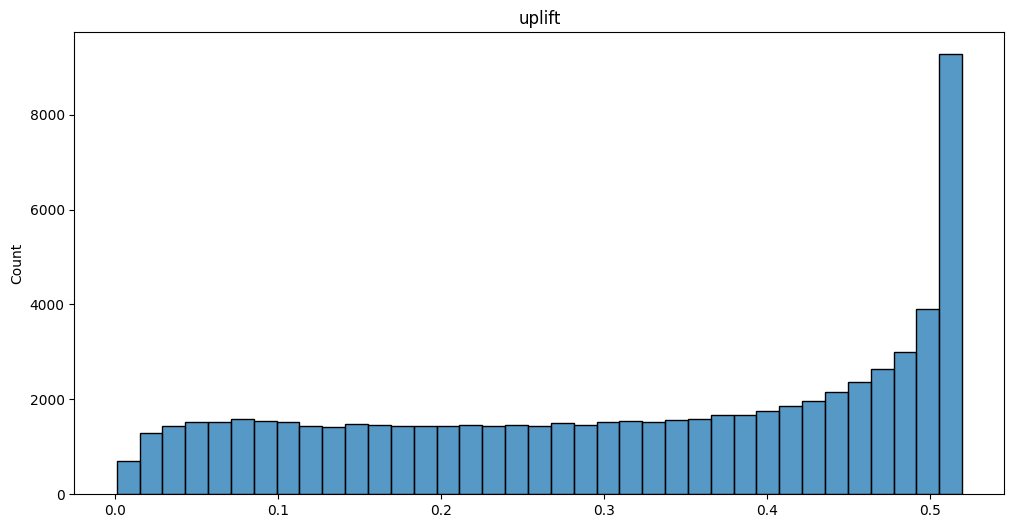

In [76]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(data = uplift_pd, x=uplift).set_title('uplift')
plt.show()

In [77]:
!pip install causalml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 75.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 73.5 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.2
    Uninstalling scikit-learn-1.3.2:
      Successfully uninstalled scikit-learn-1.3.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-learn]


In [78]:
!pip install scikit-uplift


In [79]:
!pip install optuna

In [80]:
!pip install catboost

In [81]:
pip install scikit-uplift

  Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached scikit_learn-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (10.8 MB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-learn]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
causalml 0.15.5 requires sci

In [83]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split,
                                     cross_validate,
                                     StratifiedKFold)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

from causalml.dataset import make_uplift_classification
from causalml.inference.tree import UpliftRandomForestClassifier

import optuna

from catboost import CatBoostClassifier

from sklift.models import (SoloModel,
                           TwoModels,
                           ClassTransformation,
                           ClassTransformationReg)
from sklift.metrics import (uplift_at_k,
                            uplift_auc_score,
                            qini_auc_score,
                            make_uplift_scorer)
from sklift.viz import plot_qini_curve, plot_uplift_curve

ImportError: cannot import name 'validate_data' from 'sklearn.utils.validation' (/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py)

<h2>4. Подготовка ответа в требуемом формате и подготовка выводов (6 баллов)</h2>

a) Сделайте скоринг нужных клиентов, подготовьте ответ в требуемом формате

б) Сделайте краткую аналитику того, какой канал взаимодействия наиболее предпочтителен

в) Сделайте выводы по проделанной работе

**Комментарий по заданиям и оцениванию:**

* Подготовлен только ответ - **1 балл**
* Подготовлен содержательный вывод по проделанной работе - **4 балла**
* Корректно принято решение об отправке/не отправке коммуникации клиентам в зависимости от значений Uplift - **1 балл**

In [ ]:
# ваш код здесь

### ваши выводы здесь